In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [10]:
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


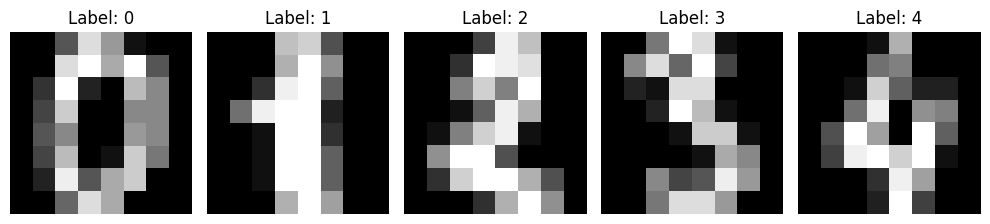

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("some_visual_examples.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1168
Test size: 629


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=600, random_state=42),
    "SVM": SVC()
}

In [28]:
results = []

with open("compare_results.txt", "w") as f:

    f.write("MODEL PARAMETERS\n")
    f.write("----------------\n")
    f.write("test_size = 0.35\n")
    f.write("random_state = 42\n")
    f.write("n_estimators = 600\n")
    f.write("max_iter = 2000\n\n")

    f.write("CLASSIFICATION REPORTS\n")
    f.write("======================\n\n")

    for name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Accuracy
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy": acc
        })

        # Print in notebook
        print(f"\n{'='*50}")
        print(f"Model: {name}")
        print(f"{'='*50}")
        print(f"Accuracy: {acc:.4f}\n")
        print(classification_report(y_test, y_pred))

        # Save to file
        f.write(f"MODEL: {name}\n")
        f.write("----------------------------\n")
        f.write(f"Accuracy: {acc:.4f}\n\n")
        f.write(classification_report(y_test, y_pred))
        f.write("\n\n")


Model: Logistic Regression
Accuracy: 0.9682

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       0.95      0.92      0.93        61
           2       0.98      1.00      0.99        57
           3       0.98      0.97      0.98        62
           4       0.98      0.97      0.98        66
           5       0.95      0.95      0.95        76
           6       0.97      0.98      0.97        59
           7       0.97      0.98      0.98        65
           8       0.93      0.96      0.95        55
           9       0.97      0.96      0.96        71

    accuracy                           0.97       629
   macro avg       0.97      0.97      0.97       629
weighted avg       0.97      0.97      0.97       629


Model: Random Forest
Accuracy: 0.9777

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.97      1.00      0.98   

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
2,SVM,0.987281
1,Random Forest,0.977742
0,Logistic Regression,0.968203


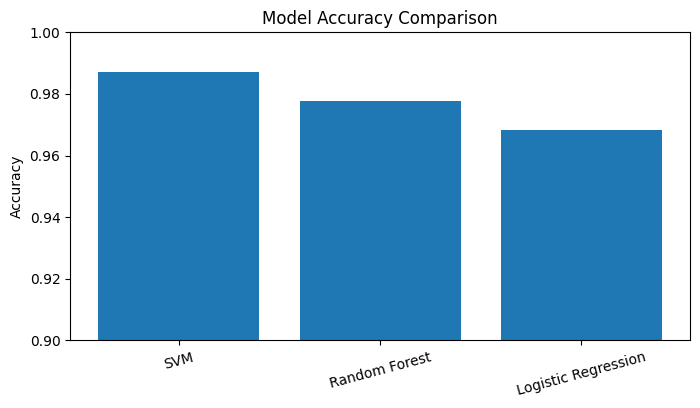

In [31]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0.9, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.savefig("vualization_of_results.png", dpi=300, bbox_inches="tight")
plt.show()

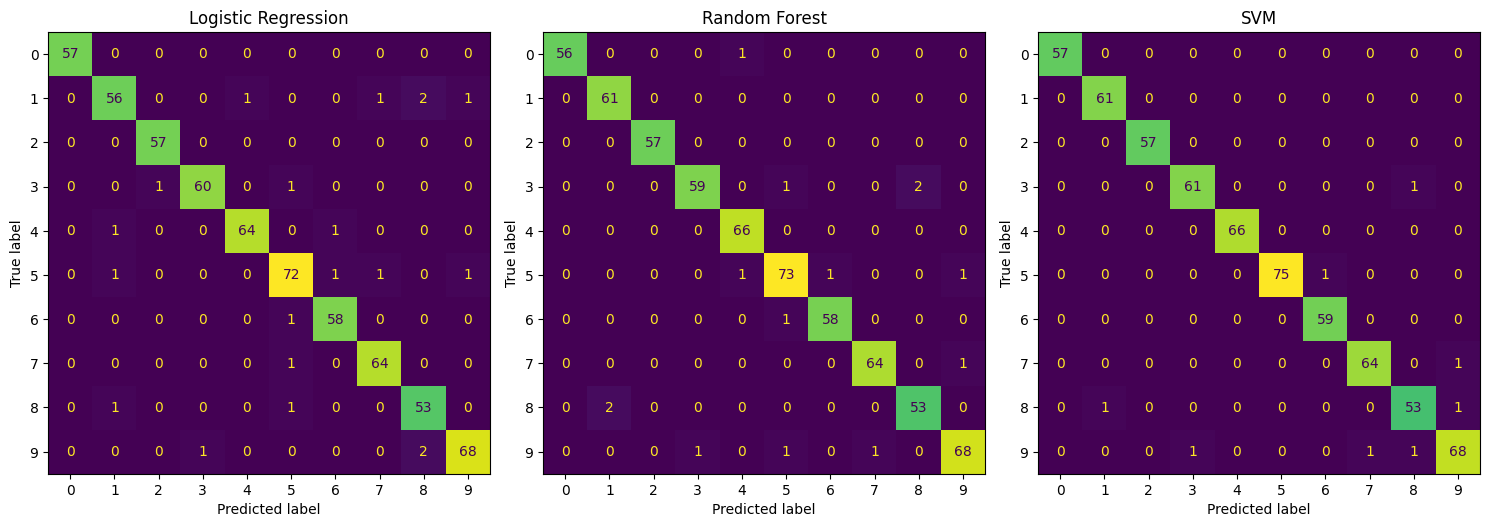

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, (name, model) in zip(axes, models.items()):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    
    ax.set_title(name)

plt.tight_layout()

plt.savefig("confusion_matrices_comparison.png",
            dpi=300, bbox_inches="tight")

plt.show()

In [35]:
results_df.to_csv("compare_models_results.csv", index=False)
print("Results saved to compare_models_results.csv")

Results saved to compare_models_results.csv
